DAY 6: CROSS-VALIDATION

📊 Dataset: 569 samples, 30 features

📊 Single Train/Test Split: 0.9649 (96.5%)
   ⚠️ But this depends on ONE lucky/unlucky split!

K-FOLD CROSS-VALIDATION

📊 5-Fold CV Results:
  Fold 1: 0.9561 (95.6%)
  Fold 2: 0.9649 (96.5%)
  Fold 3: 0.9386 (93.9%)
  Fold 4: 0.9649 (96.5%)
  Fold 5: 0.9646 (96.5%)

  Mean CV Accuracy: 0.9578 (95.8%)
  Std Deviation: 0.0102

COMPARING DIFFERENT K VALUES

  K=3:
    Mean: 0.9490 (94.9%)
    Std: 0.0051

  K=5:
    Mean: 0.9578 (95.8%)
    Std: 0.0102

  K=10:
    Mean: 0.9631 (96.3%)
    Std: 0.0094

  K=15:
    Mean: 0.9631 (96.3%)
    Std: 0.0251

STRATIFIED K-FOLD (Preserves class balance)

  Regular KFold:     0.9578 ± 0.0102
  Stratified KFold:  0.9561 ± 0.0123


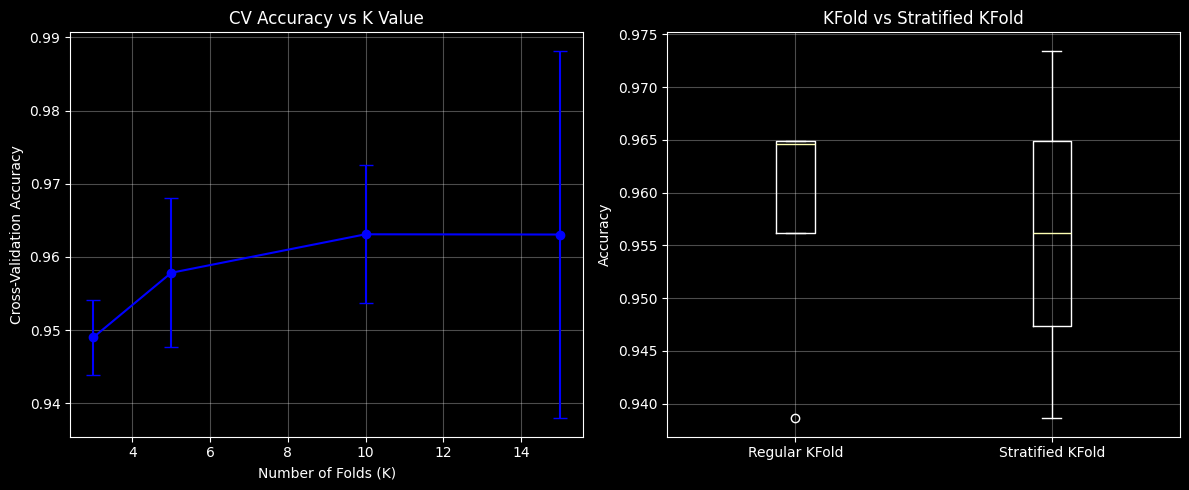


PRACTICAL GUIDELINES

📌 FOR SMALL DATASETS (<1000 samples):
   - Use K=5 or K=10
   - Stratified KFold recommended
   - Report: mean ± std

📌 FOR LARGE DATASETS (>10000 samples):
   - Use K=3 or K=5 (faster)
   - Simple KFold is fine

📌 FOR IMBALANCED DATA:
   - ALWAYS use Stratified KFold
   - Preserves class percentages

📌 REPORTING RESULTS:
   "Accuracy: {mean:.4f} ± {std:.4f} (95% CI)"

   Example: "Accuracy: 0.965 ± 0.012"


✅ YOUR BREAST CANCER RESULT:
   Accuracy: 0.9578 ± 0.0102
   95% Confidence Interval: [0.9375, 0.9782]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score

print("=" * 60)
print("DAY 6: CROSS-VALIDATION")
print("=" * 60)

# Load data
data = load_breast_cancer()
X = data.data
y = data.target

print(f"\n📊 Dataset: {X.shape[0]} samples, {X.shape[1]} features")

# ============================================
# PART 1: SIMPLE TRAIN/TEST (What you've been doing)
# ============================================

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
single_score = rf.score(X_test, y_test)

print(f"\n📊 Single Train/Test Split: {single_score:.4f} ({single_score*100:.1f}%)")
print("   ⚠️ But this depends on ONE lucky/unlucky split!")

# ============================================
# PART 2: K-FOLD CROSS-VALIDATION
# ============================================

print("\n" + "=" * 60)
print("K-FOLD CROSS-VALIDATION")
print("=" * 60)

# 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=kfold)

print(f"\n📊 5-Fold CV Results:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score*100:.1f}%)")

print(f"\n  Mean CV Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.1f}%)")
print(f"  Std Deviation: {cv_scores.std():.4f}")

# ============================================
# PART 3: COMPARE DIFFERENT K VALUES
# ============================================

print("\n" + "=" * 60)
print("COMPARING DIFFERENT K VALUES")
print("=" * 60)

k_values = [3, 5, 10, 15]
cv_means = []
cv_stds = []

for k in k_values:
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X, y, cv=kfold)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"\n  K={k}:")
    print(f"    Mean: {scores.mean():.4f} ({scores.mean()*100:.1f}%)")
    print(f"    Std: {scores.std():.4f}")

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.errorbar(k_values, cv_means, yerr=cv_stds, fmt='bo-', capsize=5)
plt.xlabel('Number of Folds (K)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('CV Accuracy vs K Value')
plt.grid(True, alpha=0.3)

# ============================================
# PART 4: STRATIFIED K-FOLD (Better for imbalanced data)
# ============================================

print("\n" + "=" * 60)
print("STRATIFIED K-FOLD (Preserves class balance)")
print("=" * 60)

# Regular KFold (might have imbalanced folds)
regular_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
regular_scores = cross_val_score(rf, X, y, cv=regular_kfold)

# Stratified KFold (maintains same class percentage in each fold)
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_scores = cross_val_score(rf, X, y, cv=stratified_kfold)

print(f"\n  Regular KFold:     {regular_scores.mean():.4f} ± {regular_scores.std():.4f}")
print(f"  Stratified KFold:  {stratified_scores.mean():.4f} ± {stratified_scores.std():.4f}")

# ============================================
# PART 5: VISUALIZE FOLD DIFFERENCES
# ============================================

plt.subplot(1, 2, 2)
plt.boxplot([regular_scores, stratified_scores], tick_labels=['Regular KFold', 'Stratified KFold'])
plt.ylabel('Accuracy')
plt.title('KFold vs Stratified KFold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PART 6: PRACTICAL RECOMMENDATION
# ============================================

print("\n" + "=" * 60)
print("PRACTICAL GUIDELINES")
print("=" * 60)

print("""
📌 FOR SMALL DATASETS (<1000 samples):
   - Use K=5 or K=10
   - Stratified KFold recommended
   - Report: mean ± std

📌 FOR LARGE DATASETS (>10000 samples):
   - Use K=3 or K=5 (faster)
   - Simple KFold is fine

📌 FOR IMBALANCED DATA:
   - ALWAYS use Stratified KFold
   - Preserves class percentages

📌 REPORTING RESULTS:
   "Accuracy: {mean:.4f} ± {std:.4f} (95% CI)"

   Example: "Accuracy: 0.965 ± 0.012"
""")

print(f"\n✅ YOUR BREAST CANCER RESULT:")
print(f"   Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   95% Confidence Interval: [{cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f}]")